# TLUSTY binary diagnostic plot — read saved models

This notebook reads the fit parameters from the Google Sheet, automatically finds all observations of the object, then reads the two saved components and the combined binary model from the matching observation folder in `G:\\Shared drives\\BinamicsOstars\\TLUSTY Models`.

Normally, you only need to change `observation_name`.


In [48]:
import specpolFlow as pol
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib.gridspec import GridSpec

# Paths
obs_folder = Path(r"G:\Shared drives\BinamicsOstars\DataFromEve\spectra_tovero")
model_root = Path(r"G:\Shared drives\BinamicsOstars\TLUSTY Models")
save_folder = Path(r"G:\Shared drives\BinamicsOstars\TLUSTY Fitting Diagnostic Plots")

# Google Sheet
sheet_id = "1Q9ZFGf2nsH7lBqPRTyT4Xwwmwxs14qCli5zr1JrpOzs"
sheet_name = "Sheet2"
sheet_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"
df = pd.read_csv(sheet_url)

def get_params_from_sheet(observation_name):
    row = df.loc[df["obs"] == observation_name]
    if row.empty:
        raise ValueError(f"{observation_name} not found in {sheet_name}")
    row = row.iloc[0]

    return {
        "R2R1": float(row["R2R1"]), "vturb": int(row["vturb"]),
        "grid_1": str(row["grid1"]), "grid_2": str(row["grid2"]),
        "teff1": int(row["Teff1"]), "logg1": int(row["logg1"]),
        "vsini1": int(row["vsini1"]), "vrad1": int(row["vrad1"]),
        "teff2": int(row["Teff2"]), "logg2": int(row["logg2"]),
        "vsini2": int(row["vsini2"]), "vrad2": int(row["vrad2"]),
    }

def read_saved_binary(observation_name, p):
    obsname = observation_name.replace("_rn.s", "")
    folder = model_root / obsname

    name1 = f"T{p['teff1']}G{p['logg1']}_v{p['vsini1']}_vr{p['vrad1']}.s"
    name2 = f"T{p['teff2']}G{p['logg2']}_v{p['vsini2']}_vr{p['vrad2']}.s"

    files = {
        "Component 1": folder / name1,
        "Component 2": folder / name2,
        "Binary Model": folder / "binary_model.s",
    }

    missing = [str(path) for path in files.values() if not path.exists()]
    if missing:
        raise FileNotFoundError("Missing saved model file(s):\n" + "\n".join(missing))

    return (
        pol.read_spectrum(files["Component 1"]),
        pol.read_spectrum(files["Component 2"]),
        pol.read_spectrum(files["Binary Model"]),
    )


In [49]:
# =========================
# SELECT OBSERVATION
# =========================
observation_name = "xzcep_E_1648416pnm_rn.s"
object_name = observation_name.split("_")[0]

# Read all observations for this object
obs = sorted(f.name for f in obs_folder.glob(f"{object_name}*.s"))
if not obs:
    raise FileNotFoundError(f"No observations found for {object_name}")
if observation_name not in obs:
    raise ValueError(f"{observation_name} not found among:\n{obs}")

specs, labels = [], []
for filename in obs:
    s = pol.read_spectrum(obs_folder / filename).merge_orders(mode="trim")
    specs.append(s)
    labels.append(filename.replace("_rn.s", ""))

fit_index = obs.index(observation_name)
spec = specs[fit_index]

# Read parameters + saved model spectra
params_B = get_params_from_sheet(observation_name)
component_1, component_2, model = read_saved_binary(observation_name, params_B)
components = [(component_1, "Component 1"), (component_2, "Component 2")]

print(f"Found {len(obs)} observation(s) for {object_name}")
print("Fitting:", observation_name)
print("Parameters:", params_B)
print("Model folder:", model_root / observation_name.replace("_rn.s", ""))


Found 1 observation(s) for xzcep
Fitting: xzcep_E_1648416pnm_rn.s
Parameters: {'R2R1': 1.25, 'vturb': 2, 'grid_1': 'O', 'grid_2': 'B', 'teff1': 27500, 'logg1': 350, 'vsini1': 180, 'vrad1': 20, 'teff2': 25000, 'logg2': 300, 'vsini2': 100, 'vrad2': -260}
Model folder: G:\Shared drives\BinamicsOstars\TLUSTY Models\xzcep_E_1648416pnm


In [22]:
# Plotting windows / line markers
windows = [(400,412), (432,440), (445,455), (467,473), (485,495)]

lines_H = [
    (410.1, "Hδ 4101"),
    (434.0, "Hγ 4340"),
    (486.1, "Hβ 4861"),
]

lines_He = [
    (402.6, "He I/II 4026"), (420.0, "He II 4200"),
    (438.7, "He I 4387"), (447.1, "He I 4471"),
    (448.1, "Mg II 4481"), (454.1, "He II 4541"),
    (468.6, "He II 4686"), (471.3, "He I 4713"),
    (492.2, "He I 4922"), (501.6, "He I 5016"),
    (580.1, "C IV 5801"), (581.1, "C IV 5811"),
]

def mark_lines(a, xmin, xmax):
    for wl, label in lines_H:
        if xmin <= wl <= xmax:
            a.axvline(wl, color="red", ls="--", lw=0.7)
            a.text(wl+0.12, 0.7, label, color="red", fontsize=12,
                   rotation=-90, ha="left", va="top")

    for wl, label in lines_He:
        if xmin <= wl <= xmax:
            a.axvline(wl, color="purple", ls="--", lw=0.7)
            a.text(wl+0.12, 0.75, label, color="purple", fontsize=12,
                   rotation=-90, ha="left", va="top")


In [52]:
# Notes
notes = f"""
Object: {object_name}
This object has a total of {len(obs)} observations: {obs}. The lines appear to be multi-component, with a very shallow component on the redshifted side. If this redshifted 
component is indeed a component from binary, then this give clear RV shift that originates from binarity. 
We provide the following TLUSTY binary model. Almost all the lines show some discrepancies in both components.  
$T_{{\\rm eff,1}}$ = {params_B['teff1']} K, $\\log g_1$ = {params_B['logg1']/100:.2f}, $v\\sin i_1$ = {params_B['vsini1']} km/s, $v_{{\\rm rad,1}}$ = {params_B['vrad1']} km/s
$T_{{\\rm eff,2}}$ = {params_B['teff2']} K, $\\log g_2$ = {params_B['logg2']/100:.2f}, $v\\sin i_2$ = {params_B['vsini2']} km/s, $v_{{\\rm rad,2}}$ = {params_B['vrad2']} km/s
$R_2/R_1$ = {params_B['R2R1']}, $v_{{\\rm turb}}$ = {params_B['vturb']} km/s
"""

notes_red = f"""
For Vero: check my parameters for this observation."""

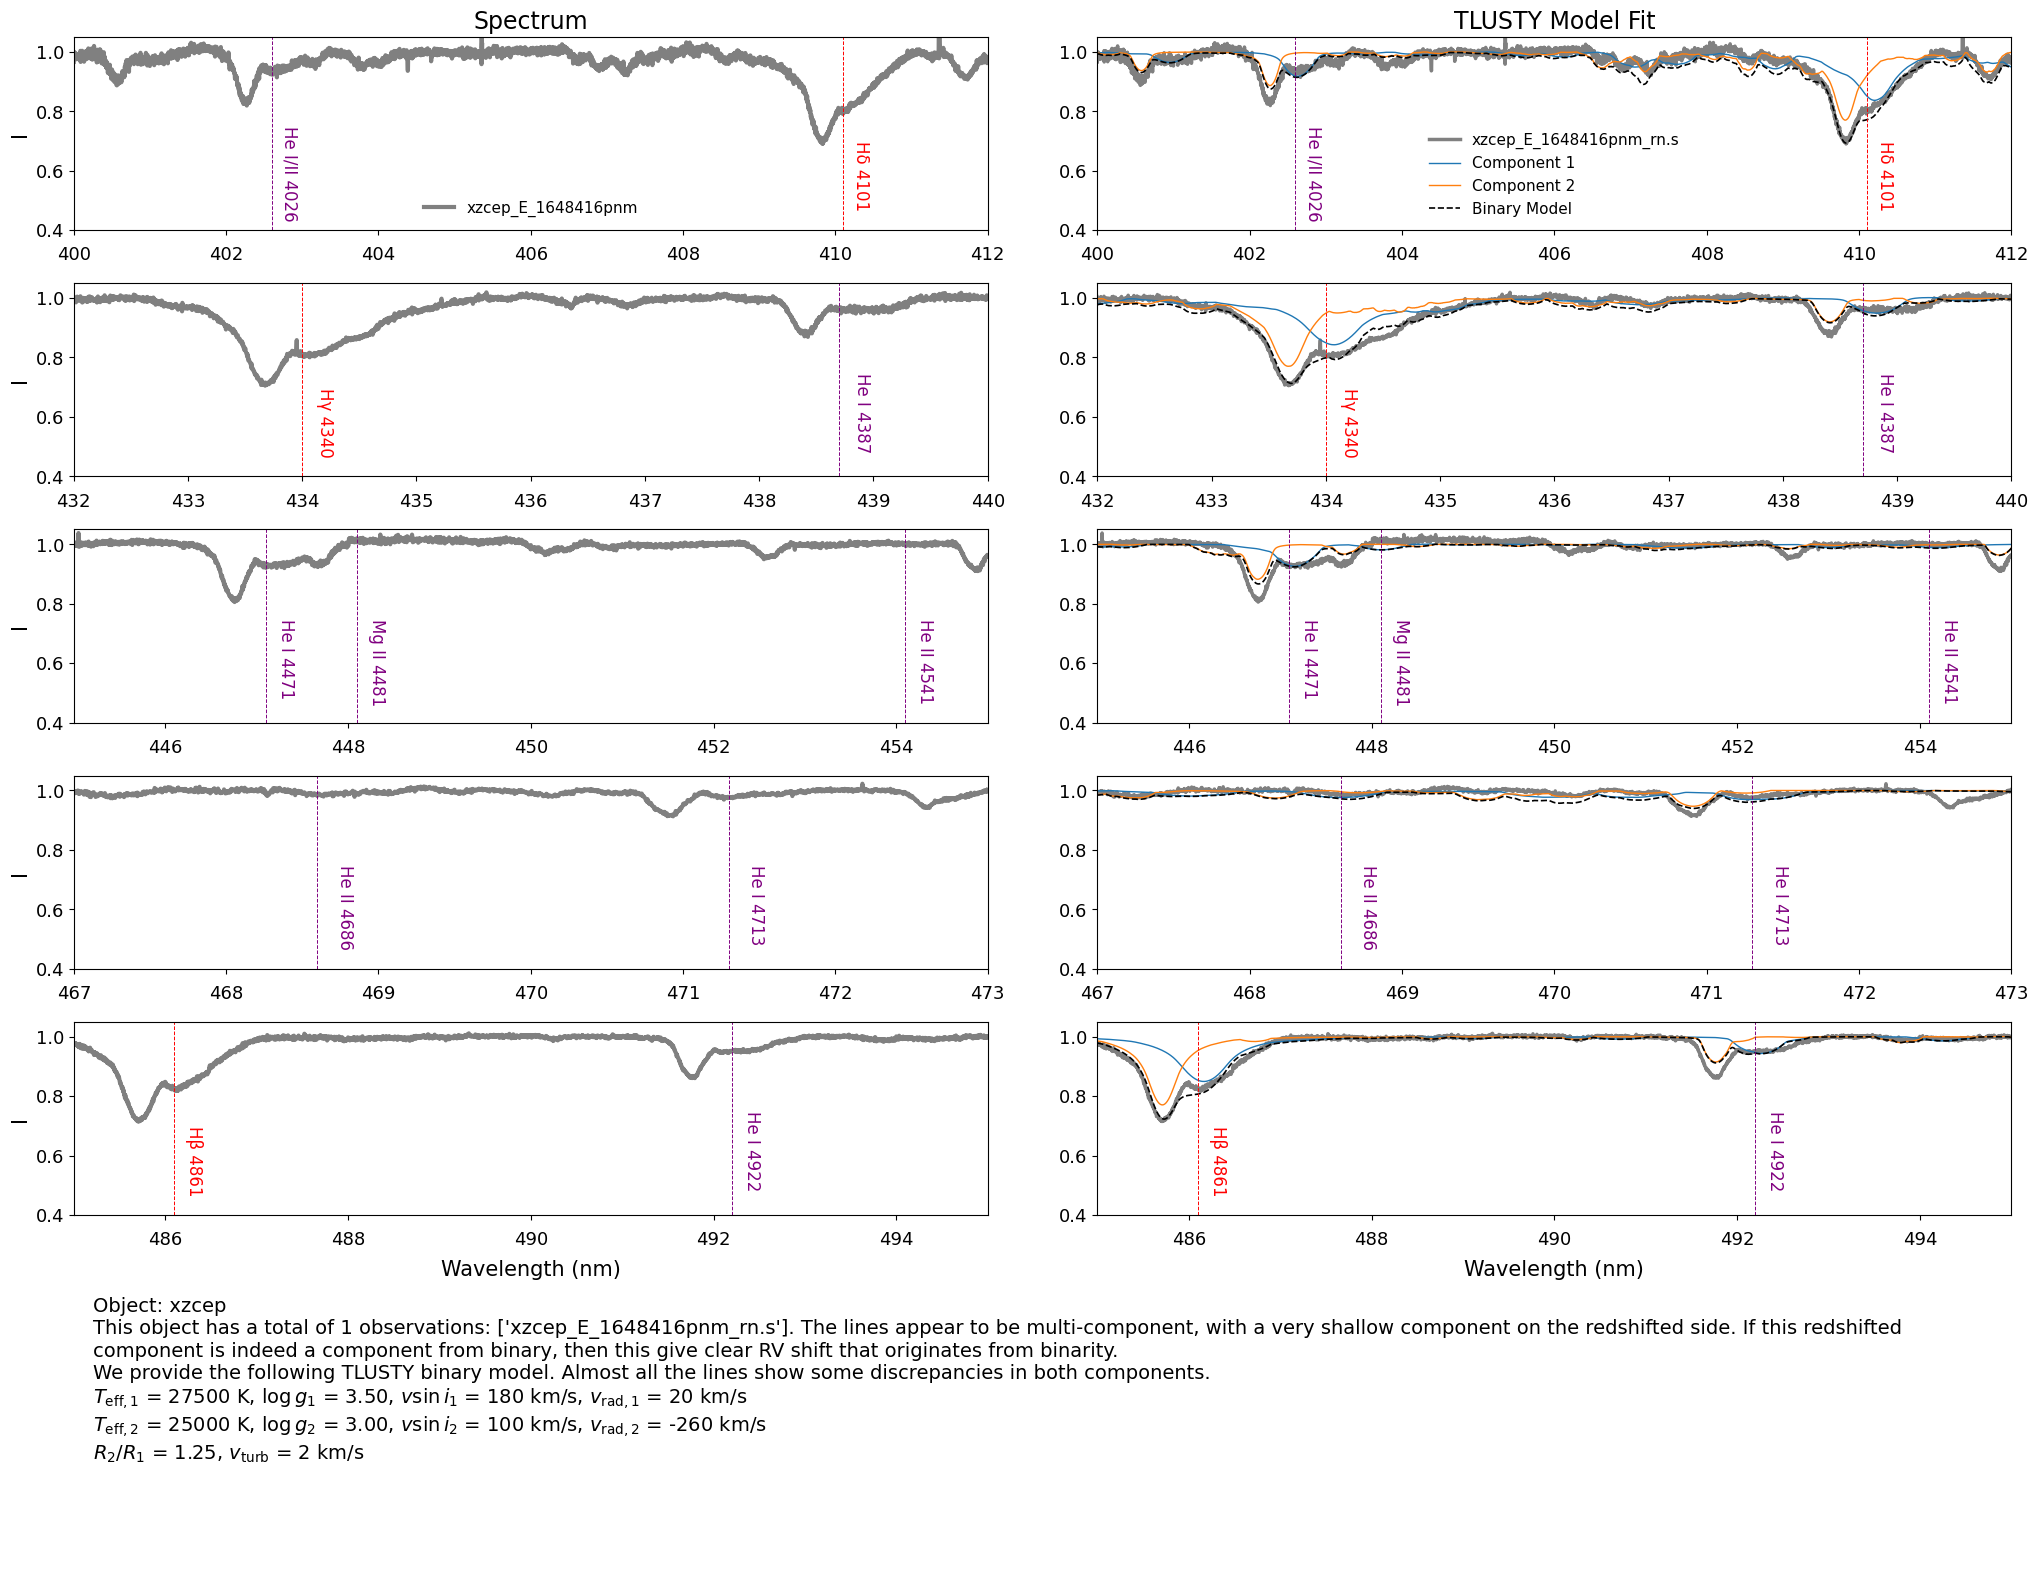

In [53]:
# =========================
# SIDE-BY-SIDE DIAGNOSTIC PLOT
# =========================
y_lim = 0.4

fig = plt.figure(figsize=(25,20))
gs = GridSpec(6, 2, figure=fig, height_ratios=[1,1,1,1,1,1.6],
              hspace=0.25, wspace=0.12)

ax_obs = [fig.add_subplot(gs[i,0]) for i in range(5)]
ax_model = [fig.add_subplot(gs[i,1]) for i in range(5)]
ax_text = fig.add_subplot(gs[5,:])

plt.rcParams.update({
    "font.size":14, "axes.titlesize":17, "axes.labelsize":15,
    "xtick.labelsize":13, "ytick.labelsize":13, "legend.fontsize":11
})

# LHS: observations
for i, (xmin, xmax) in enumerate(windows):
    a = ax_obs[i]

    for j, (spec_obs, label) in enumerate(zip(specs, labels)):
        if j != fit_index:
            a.plot(spec_obs.wl, spec_obs.specI, lw=1, ls="--", label=label)

    a.plot(spec.wl, spec.specI, lw=3, color="grey", label=labels[fit_index])
    a.set(xlim=(xmin,xmax), ylim=(y_lim,1.05), ylabel="I")
    a.tick_params(axis="x", pad=8)
    mark_lines(a, xmin, xmax)

ax_obs[0].legend(loc="lower center", frameon=False)
ax_obs[0].set_title("Spectrum")
ax_obs[-1].set_xlabel("Wavelength (nm)", labelpad=8)

# RHS: saved binary model + components
for i, (xmin, xmax) in enumerate(windows):
    a = ax_model[i]

    a.plot(spec.wl, spec.specI, color="grey", lw=2.5, label=observation_name)

    for component, label in components:
        a.plot(component.wl/10, component.specI, lw=1, label=label)

    a.plot(model.wl, model.specI, color="black", ls="--", lw=1.2,
           label="Binary Model")

    a.set(xlim=(xmin,xmax), ylim=(y_lim,1.05))
    a.tick_params(axis="x", pad=8)
    mark_lines(a, xmin, xmax)

ax_model[0].legend(loc="lower center", frameon=False)
ax_model[0].set_title("TLUSTY Model Fit")
ax_model[-1].set_xlabel("Wavelength (nm)", labelpad=8)

# Notes + save
ax_text.axis("off")
ax_text.text(0.01, 0.98, notes, va="top", fontsize=14,
             wrap=True, transform=ax_text.transAxes)
# ax_text.text(0.01, 0.08, notes_red,color='red', va="top", fontsize=12,
#              wrap=True, transform=ax_text.transAxes)
output_file = save_folder / f"{observation_name.replace('_rn.s','')}_diagnostics.pdf"
plt.savefig(output_file, dpi=300, bbox_inches="tight", pad_inches=0.3)
plt.show()

